# Public Transport Telemetry - MVP

Minimal simulation of transit and weather telemetry.
Structured in Bronze -> Silver -> Gold layers

In [0]:
# Imports
import uuid
import time, random
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import *

## Bronze layer

Append-only storage for raw transit and weather events.
Only minimal normalization is applied.

In [0]:
# Use UTC for consistent event-time handling
print("session timeZone =", spark.conf.get("spark.sql.session.timeZone"))
spark.conf.set("spark.sql.session.timeZone", "UTC")

# Use a database for the MVP (managed storage, no explicit DBFS paths)
spark.sql("CREATE DATABASE IF NOT EXISTS azure_streaming_mvp")
spark.sql("USE azure_streaming_mvp")

RESET = True # drop and recreate tables

def reset_tables():
  spark.sql("DROP TABLE IF EXISTS bronze_events")
  spark.sql("DROP TABLE IF EXISTS silver_transit_metrics")
  spark.sql("DROP TABLE IF EXISTS silver_weather_metrics")
  # For reference
  # spark.sql("DROP TABLE IF EXISTS silver_metrics")
  print("Tables dropped: bronze_events, silver_transit_metrics, silver_weather_metrics")

# Clean slate
if RESET:
  reset_tables()

# Create an empty Bronze table with a fixed schema (append-only)
spark.sql("""
CREATE TABLE bronze_events (
  event_id STRING,
  -- event_time_raw: Raw event time from source (UTC, ISO 8601)
  event_time_raw STRING,
  source STRING,
  entity_type STRING,
  entity_id STRING,
  metric STRING,
  value DOUBLE,
  unit STRING,
  attrs MAP<STRING, STRING>,
  -- event_time_ts: Parsed event time used for windowing
  event_time_ts TIMESTAMP,
  -- ingest_time_ts: Ingestion timestamp (system time)
  ingest_time_ts TIMESTAMP
)
USING DELTA
-- Use Delta Lake (append-only Bronze storage)
""")

session timeZone = Etc/UTC
Tables dropped: bronze_events, silver_transit_metrics, silver_weather_metrics


DataFrame[]

## Simulated transit telemetry ingestion

Generate synthetic vehicle events per route and append to Bronze

In [0]:
ROUTES = ["M1", "M2", "T1", "R10", "B1", "B2", "X3", "X7"]
TIME_SPAN_MINUTES = 60 # simulation window (minutes)

def make_event(i):
    metric = random.choice(["delay_sec", "occupancy"])
    value = random.randint(-30, 600) if metric == "delay_sec" else random.randint(0, 80)

    # Randomize event time within last TIME_SPAN_MINUTES
    offset_sec = random.randint(0, TIME_SPAN_MINUTES * 60)
    event_epoch = int(time.time()) - offset_sec # UTC epoch seconds
    event_time_raw = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime(event_epoch))

    return {
        "event_id": str(uuid.uuid4()),
        "event_time_raw": event_time_raw,
        "source": "sim_telemetry",
        "entity_type": "vehicle",
        "entity_id": f"veh_{random.randint(100, 130)}",
        "metric": metric,
        "value": float(value),
        "unit": "sec" if metric == "delay_sec" else "pct",
        "attrs": {"route_id": random.choice(ROUTES),
                  "stop_id": str(random.randint(1, 60))}
    }

def ingest_batch(batch_id, n=200):
    # Generate simulated events
    rows = [make_event(i) for i in range(n)]
    # Create Spark DataFrame
    df = spark.createDataFrame(rows)    

    # Parse event time and add ingest timestamp
    df2 = (df
           .withColumn("event_time_ts", F.to_timestamp("event_time_raw", "yyyy-MM-dd'T'HH:mm:ss'Z'"))
           .withColumn("ingest_time_ts", F.current_timestamp())
    )

    # Append to Bronze table
    (df2.write.mode("append").saveAsTable("bronze_events"))
    print(f"Batch {batch_id} appended to bronze_events: {n} rows")

ingest_batch(0, 200)
display(spark.table("bronze_events").orderBy(F.col("ingest_time_ts").desc()).limit(10))

Batch 0 appended to bronze_events: 200 rows


event_id,event_time_raw,source,entity_type,entity_id,metric,value,unit,attrs,event_time_ts,ingest_time_ts
7b42eca5-2769-4f9b-a5ae-9dcb640eb914,2026-02-22T19:43:39Z,sim_telemetry,vehicle,veh_105,occupancy,30.0,pct,"Map(route_id -> M1, stop_id -> 9)",2026-02-22T19:43:39.000Z,2026-02-22T20:09:44.384Z
2d476aa8-6043-410d-b86c-ea98f59893b5,2026-02-22T19:45:22Z,sim_telemetry,vehicle,veh_109,occupancy,30.0,pct,"Map(route_id -> B1, stop_id -> 40)",2026-02-22T19:45:22.000Z,2026-02-22T20:09:44.384Z
5986ab62-d9bd-451c-8288-cc62cc9071b8,2026-02-22T20:02:03Z,sim_telemetry,vehicle,veh_125,delay_sec,386.0,sec,"Map(route_id -> T1, stop_id -> 27)",2026-02-22T20:02:03.000Z,2026-02-22T20:09:44.384Z
1a3e9203-5a55-4553-9c4a-fef47b921ea8,2026-02-22T19:25:27Z,sim_telemetry,vehicle,veh_110,occupancy,76.0,pct,"Map(route_id -> M1, stop_id -> 11)",2026-02-22T19:25:27.000Z,2026-02-22T20:09:44.384Z
5554c954-68f7-45f3-b83b-9d5c8110dbe9,2026-02-22T19:34:19Z,sim_telemetry,vehicle,veh_129,occupancy,46.0,pct,"Map(route_id -> B2, stop_id -> 9)",2026-02-22T19:34:19.000Z,2026-02-22T20:09:44.384Z
97d19b6a-0506-498b-9b23-2a8216177c2e,2026-02-22T19:39:43Z,sim_telemetry,vehicle,veh_112,occupancy,3.0,pct,"Map(route_id -> X3, stop_id -> 51)",2026-02-22T19:39:43.000Z,2026-02-22T20:09:44.384Z
ddf37e82-aef4-4dfd-8080-c41bcf4a87c4,2026-02-22T19:15:40Z,sim_telemetry,vehicle,veh_103,occupancy,12.0,pct,"Map(route_id -> B1, stop_id -> 54)",2026-02-22T19:15:40.000Z,2026-02-22T20:09:44.384Z
42edefc4-6de2-4fc6-8874-32c3ac0e57bb,2026-02-22T19:16:09Z,sim_telemetry,vehicle,veh_112,delay_sec,544.0,sec,"Map(route_id -> M2, stop_id -> 5)",2026-02-22T19:16:09.000Z,2026-02-22T20:09:44.384Z
c4f934d5-051f-48b2-8a6e-83f1ad19a1b6,2026-02-22T19:53:10Z,sim_telemetry,vehicle,veh_101,delay_sec,31.0,sec,"Map(route_id -> R10, stop_id -> 52)",2026-02-22T19:53:10.000Z,2026-02-22T20:09:44.384Z
17ce80a3-5854-47c3-a947-748f6656f012,2026-02-22T19:32:00Z,sim_telemetry,vehicle,veh_119,delay_sec,516.0,sec,"Map(route_id -> R10, stop_id -> 4)",2026-02-22T19:32:00.000Z,2026-02-22T20:09:44.384Z


## Silver layer: transit metrics

Aggregate route events into 5-minute windows and compute basic volume and latency signals.

In [0]:
TRANSIT_WINDOW = "5 minutes"    # window size
LOOKBACK_MINUTES = 60           # filter recent events
LATE_THRESHOLD_SEC = 120        # late-event threshold

In [0]:
bronze_all = spark.table("bronze_events")

# Filter to simulated transit events
bronze_recent = (
    bronze_all
    .filter(F.col("source") == F.lit("sim_telemetry"))
    .filter(F.col("event_time_ts") >= (F.current_timestamp() - F.expr(f"INTERVAL 1 MINUTE * {LOOKBACK_MINUTES}")))
)

bronze_enriched = (
    bronze_recent
    .withColumn("route_id", F.col("attrs").getItem("route_id"))
    .withColumn(
        "ingest_delay_sec_raw",
        F.unix_timestamp("ingest_time_ts") - F.unix_timestamp("event_time_ts")
    )
    # Negative delay => clock skew (event_time > ingest_time). Keep raw, clamp for metrics.
    .withColumn("is_clock_skew", F.col("ingest_delay_sec_raw") < F.lit(0))
    .withColumn("ingest_delay_sec", F.greatest(F.col("ingest_delay_sec_raw"), F.lit(0)))
    .withColumn("is_late_event", F.col("ingest_delay_sec") > F.lit(LATE_THRESHOLD_SEC))
)

# Windowed aggeration
silver_transit = (
    bronze_enriched
    .groupBy(
        F.window("event_time_ts", TRANSIT_WINDOW).alias("window"),
        F.col("metric"),
        F.col("route_id")
    )
    .agg(
        F.avg("value").alias("avg_value"),
        F.count(F.lit(1)).alias("n_events"),
        F.avg(F.col("ingest_delay_sec")).alias("avg_ingest_delay_sec"),
        F.sum(F.col("is_late_event").cast("int")).alias("n_late_events"),
        F.sum(F.col("is_clock_skew").cast("int")).alias("n_clock_skew")
    )
    .withColumn("late_event_rate", 
                F.when(F.col("n_events") == 0, F.lit(0.0))
                .otherwise(F.col("n_late_events") / F.col("n_events"))
    )
    .select(
        F.col("window.start").alias("window_start"),
        F.col("window.end").alias("window_end"),
        F.col("metric"),
        F.col("route_id"),
        F.col("avg_value"),
        F.col("n_events"),
        F.col("avg_ingest_delay_sec"),
        F.col("n_late_events"),
        F.col("late_event_rate"),
        F.col("n_clock_skew")
    )
)

# Persist Silver output
(silver_transit.write.mode("overwrite").saveAsTable("silver_transit_metrics"))
display(spark.table("silver_transit_metrics").orderBy(F.col("window_start").desc()).limit(20))

window_start,window_end,metric,route_id,avg_value,n_events,avg_ingest_delay_sec,n_late_events,late_event_rate,n_clock_skew
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,occupancy,B1,68.5,2,86.0,0,0.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,occupancy,R10,43.0,1,135.0,1,1.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,delay_sec,B2,178.0,2,27.5,0,0.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,occupancy,X7,70.0,1,129.0,1,1.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,delay_sec,T1,-6.0,1,270.0,1,1.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,delay_sec,R10,35.0,1,3.0,0,0.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,delay_sec,M2,-11.0,1,218.0,1,1.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,occupancy,M2,63.0,1,13.0,0,0.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,delay_sec,M1,230.0,1,216.0,1,1.0,0
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,delay_sec,X7,502.0,1,40.0,0,0.0,0


## Validation checks

Basic sanity checks on Silver output.

In [0]:
# Row count
spark.sql("SELECT COUNT(*) AS c FROM silver_transit_metrics").show()

# Latest window
spark.sql("""
SELECT MAX(window_end) AS latest_window_end
FROM silver_transit_metrics
""").show()

# Check duplicate keys (window_start, metric, route_id)
spark.sql("""
SELECT window_start, metric, route_id, COUNT(*) AS row_count
FROM silver_transit_metrics
GROUP BY window_start, metric, route_id
HAVING row_count > 1
""").show(truncate=False)

+---+
|  c|
+---+
|128|
+---+

+-------------------+
|  latest_window_end|
+-------------------+
|2026-02-22 20:10:00|
+-------------------+

+------------+------+--------+---------+
|window_start|metric|route_id|row_count|
+------------+------+--------+---------+
+------------+------+--------+---------+



## Weather ingestion (FMI WFS)

Fetch recent weather observations and append to Bronze.

In [0]:
import requests
import xml.etree.ElementTree as ET
import uuid
from datetime import datetime, timedelta, timezone

FMI_WFS = "https://opendata.fmi.fi/wfs"

def fetch_fmi_timevaluepair(place="helsinki", params="t2m", minutes=60):
    """
    Fetch recent FMI observations (WFS timevaluepair).

    Args:
        place: Location name used by FMI (default: "helsinki").
        params: Comma-separated FMI parameter names (e.g. "t2m", "ws_10min").
        minutes: Lookback window in minutes.

    Returns:
        Raw XML response text from FMI WFS.
    """
    now = datetime.now(timezone.utc)
    start = now - timedelta(minutes=minutes)

    q = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "getFeature",
        "storedquery_id": "fmi::observations::weather::timevaluepair",
        "place": place,
        "parameters": params,
        "starttime": start.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "endtime": now.strftime("%Y-%m-%dT%H:%M:%SZ")
    }

    r = requests.get(FMI_WFS, params=q, timeout=60)
    r.raise_for_status()
    return r.text

def parse_fmi_events(xml_text, place="helsinki"):
    """
    Parse FMI WFS timevaluepair XML into event rows.

    Extracts (time, value) points and attaches minimal station metadata
    (id, name, lat/lon) when available.

    Args:
        xml_text: Raw XML text returned by FMI WFS.
        place: Place name used for the request context (fallback id).

    Returns:
        List of dict rows compatible with the Bronze schema.
    """
    ns = {
        "wfs": "http://www.opengis.net/wfs/2.0",
        "gml": "http://www.opengis.net/gml/3.2",
        "om": "http://www.opengis.net/om/2.0",
        "wml2": "http://www.opengis.net/waterml/2.0",
        "target": "http://xml.fmi.fi/namespace/om/atmosphericfeatures/1.1",
        "xlink": "http://www.w3.org/1999/xlink",
    }

    def safe_text(node):
        if node is None or node.text is None:
            return None
        return node.text.strip()
    
    def xlink_href(node):
        if node is None:
            return None
        return node.attrib.get("{" + ns["xlink"] + "}href")
    
    def infer_metric(href):
        if not href:
            return None
        if "param=" in href:
            tail = href.split("param=", 1)[1] # split once, in href &amp <=> &
            return tail.split("&", 1)[0] 
        return None
    
    root = ET.fromstring(xml_text)

    events = []

    for member in root.findall(".//wfs:member", ns):
        # Extract metric
        observed = member.find(".//om:observedProperty", ns)
        metric = infer_metric(xlink_href(observed)) or "t2m" # fallback

        # Station metadata
        fmisid = safe_text(member.find(".//gml:identifier", ns))
        station_name = safe_text(member.find(".//gml:Point/gml:name", ns)) or safe_text(member.find(".//gml:name", ns))
        region = safe_text(member.find(".//target:region", ns))

        pos_text = safe_text(member.find(".//gml:Point/gml:pos", ns))   # "lat lon"
        lat, lon = None, None
        if pos_text:
            parts = pos_text.split()
            if len(parts) >= 2:
                lat, lon = parts[0], parts[1]

        # Time-value pairs
        for tvp in member.findall(".//wml2:MeasurementTVP", ns):
            t = safe_text(tvp.find("./wml2:time", ns))
            v = safe_text(tvp.find("./wml2:value", ns))
            if t is None or v is None:
                continue
            try:
                v_float = float(v)
            except ValueError:
                continue

            events.append({
                "event_id": str(uuid.uuid4()),
                "event_time_raw": t,     # ISO UTC string
                "source": "fmi_weather",
                "entity_type": "weather_station",
                "entity_id": fmisid or place,
                "metric": metric,
                "value": v_float,
                "unit": "C",     # MVP: t2m is Celsius
                "attrs": {
                    "place": place,
                    "station_name": station_name,
                    "region": region,
                    "lat": lat,
                    "lon": lon,
                    "fmisid": fmisid,
                    "observed_property_href": xlink_href(observed),
                }
            })
    return events
    
def ingest_fmi(place="helsinki", params="t2m", minutes=360):
    xml_text = fetch_fmi_timevaluepair(place=place, params=params, minutes=minutes)
    rows = parse_fmi_events(xml_text, place=place)

    member_count = xml_text.count("<wfs:member")
    if not rows:
        msg = (
        f"No FMI rows parsed (place={place}, params={params}, minutes={minutes}). "
        f"WFS members found: {member_count}. "
        "Next: verify storedquery/parameters and XML namespaces; "
        "if members=0, consider widening the time window."
        )
        print(msg)
        return
    
    df = spark.createDataFrame(rows)
    df2 = (df
           .withColumn("event_time_ts", F.to_timestamp("event_time_raw", "yyyy-MM-dd'T'HH:mm:ssX"))
           .withColumn("ingest_time_ts", F.current_timestamp())
    )

    df2.write.mode("append").saveAsTable("bronze_events")
    print(f"Appended FMI events: {len(rows)}")

# Example run
ingest_fmi(place="helsinki", params="t2m", minutes=360)

Appended FMI events: 35


In [0]:
# Check duplicate keys
spark.sql("""
SELECT metric, entity_id, event_time_ts, COUNT(*) AS row_count
FROM bronze_events
WHERE source='fmi_weather'
GROUP BY metric, entity_id, event_time_ts
HAVING row_count > 1
""").show(truncate=False)

+------+---------+-------------+---------+
|metric|entity_id|event_time_ts|row_count|
+------+---------+-------------+---------+
+------+---------+-------------+---------+



In [0]:
# Preview recent FMI rows
spark.sql("""
SELECT event_time_ts,
       value,
       attrs.station_name,
       attrs.lat,
       attrs.lon
FROM bronze_events
WHERE source='fmi_weather'
ORDER BY ingest_time_ts DESC
LIMIT 10
""").show(truncate=False)

+-------------------+-----+-------------------+--------+--------+
|event_time_ts      |value|station_name       |lat     |lon     |
+-------------------+-----+-------------------+--------+--------+
|2026-02-22 15:40:00|-4.0 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 15:10:00|-3.5 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 15:20:00|-3.6 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 15:30:00|-3.8 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 14:30:00|-2.7 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 15:00:00|-3.3 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 14:20:00|-2.5 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 14:50:00|-3.1 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 14:40:00|-2.9 |Helsinki Kaisaniemi|60.17523|24.94459|
|2026-02-22 15:50:00|-4.2 |Helsinki Kaisaniemi|60.17523|24.94459|
+-------------------+-----+-------------------+--------+--------+



In [0]:
# Row count
spark.sql("""
SELECT COUNT(*) FROM bronze_events WHERE source='fmi_weather'
""").show()

+--------+
|COUNT(*)|
+--------+
|      35|
+--------+



In [0]:
# Latest event time
spark.sql("""
SELECT MAX(event_time_ts) FROM bronze_events WHERE source='fmi_weather'
""").show()

+-------------------+
| MAX(event_time_ts)|
+-------------------+
|2026-02-22 20:00:00|
+-------------------+



## Silver: weather metrics (windowed)

In [0]:
WEATHER_WINDOW = "15 minutes"
WEATHER_LOOKBACK_MINUTES = 360  # 6 hours

In [0]:
bronze_all = spark.table("bronze_events")

weather_recent = (
    bronze_all
    .filter(F.col("source") == F.lit("fmi_weather"))
    .filter(F.col("event_time_ts") >= (F.current_timestamp() - F.expr(f"INTERVAL 1 MINUTE * {WEATHER_LOOKBACK_MINUTES}")))
    .withColumn("station_id", F.col("entity_id"))   # entity_id already is fmisid or place
)

# Basic filtering for MVP
weather_clean = (
    weather_recent
    .filter(F.col("value").isNotNull())   # keep True, discard False
    # Filter extreme temperature values
    .filter(~((F.col("metric") == F.lit("t2m")) & ((F.col("value") < -60) | (F.col("value") > 60))))
)

silver_weather = (
    weather_clean
    .groupBy(
        F.window("event_time_ts", WEATHER_WINDOW).alias("window"),
        F.col("metric"),
        F.col("station_id")
    )
    .agg(
        F.avg("value").alias("avg_value"),
        F.count(F.lit(1)).alias("n_events"),
        F.avg(
            F.greatest(
                F.unix_timestamp("ingest_time_ts") - F.unix_timestamp("event_time_ts"),
                F.lit(0)
            )
        ).alias("avg_ingest_delay_sec")
    )
    .select(
        F.col("window.start").alias("window_start"),
        F.col("window.end").alias("window_end"),
        F.col("metric"),
        F.col("station_id"),
        F.col("avg_value"),
        F.col("n_events"),
        F.col("avg_ingest_delay_sec")
    )
)

# Persist Silver output
(silver_weather.write.mode("overwrite").saveAsTable("silver_weather_metrics"))
display(spark.table("silver_weather_metrics").orderBy(F.col("window_start").desc()).limit(20))

window_start,window_end,metric,station_id,avg_value,n_events,avg_ingest_delay_sec
2026-02-22T20:00:00.000Z,2026-02-22T20:15:00.000Z,t2m,100971,-7.3,1,667.0
2026-02-22T19:45:00.000Z,2026-02-22T20:00:00.000Z,t2m,100971,-7.2,1,1267.0
2026-02-22T19:30:00.000Z,2026-02-22T19:45:00.000Z,t2m,100971,-6.85,2,2167.0
2026-02-22T19:15:00.000Z,2026-02-22T19:30:00.000Z,t2m,100971,-6.0,1,3067.0
2026-02-22T19:00:00.000Z,2026-02-22T19:15:00.000Z,t2m,100971,-5.75,2,3967.0
2026-02-22T18:45:00.000Z,2026-02-22T19:00:00.000Z,t2m,100971,-5.7,1,4867.0
2026-02-22T18:30:00.000Z,2026-02-22T18:45:00.000Z,t2m,100971,-5.8,2,5767.0
2026-02-22T18:15:00.000Z,2026-02-22T18:30:00.000Z,t2m,100971,-5.5,1,6667.0
2026-02-22T18:00:00.000Z,2026-02-22T18:15:00.000Z,t2m,100971,-5.35,2,7567.0
2026-02-22T17:45:00.000Z,2026-02-22T18:00:00.000Z,t2m,100971,-5.2,1,8467.0


In [0]:
# Row Count
spark.sql("SELECT COUNT(*) AS row_count FROM silver_weather_metrics").show()

# Latest window
spark.sql("""
SELECT MAX(window_end) AS latest_window_end
FROM silver_weather_metrics
""").show()

# Check duplicate keys
spark.sql("""
SELECT window_start, metric, station_id, COUNT(*) AS row_count
FROM silver_weather_metrics
GROUP BY window_start, metric, station_id
HAVING row_count > 1
""").show(truncate=False)

+---------+
|row_count|
+---------+
|       24|
+---------+

+-------------------+
|  latest_window_end|
+-------------------+
|2026-02-22 20:15:00|
+-------------------+

+------------+------+----------+---------+
|window_start|metric|station_id|row_count|
+------------+------+----------+---------+
+------------+------+----------+---------+



## Gold: route KPI window

In [0]:
%sql
-- Gold: route KPIs per window
CREATE OR REPLACE TABLE gold_route_kpi_window
USING DELTA
AS
WITH s AS (
  SELECT *
  FROM silver_transit_metrics
),
wide AS (
  SELECT 
    window_start,
    window_end,
    route_id,
    
    -- KPI metrics
    MAX(CASE WHEN metric = 'delay_sec' THEN avg_value END) AS avg_delay_sec,
    MAX(CASE WHEN metric = 'occupancy' THEN avg_value END) AS avg_occupancy_pct,

    -- Event counts
    MAX(CASE WHEN metric = 'delay_sec' THEN n_events END) AS n_events_delay,
    MAX(CASE WHEN metric = 'occupancy' THEN n_events END) AS n_events_occupancy,

    -- Latency signals (based on delay metric)
    MAX(CASE WHEN metric = 'delay_sec' THEN late_event_rate END) AS late_rate_delay,
    MAX(CASE WHEN metric = 'delay_sec' THEN avg_ingest_delay_sec END) AS avg_ingest_delay_sec,
    MAX(CASE WHEN metric = 'delay_sec' THEN n_clock_skew END) AS n_clock_skew
        
  FROM s
  GROUP BY window_start, window_end, route_id
)
SELECT
  *,
  CASE
    WHEN COALESCE(n_clock_skew, 0.0) > 0 THEN 'CLOCK_SKEW'
    WHEN COALESCE(n_events_delay, 0) < 5 THEN 'LOW_VOLUME'
    WHEN COALESCE(late_rate_delay, 0.0) > 0.30 THEN 'HIGH_LATE_RATE'
    ELSE 'OK'
  END AS dq_flag
FROM wide;


num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT 'row_count' AS metric, CAST(COUNT(*) AS STRING) AS value
FROM gold_route_kpi_window

UNION ALL
SELECT 'latest_window_end' AS metric, CAST(MAX(window_end) AS STRING) AS value
FROM gold_route_kpi_window

UNION ALL
SELECT CONCAT('dq_flag=', dq_flag) AS metric, CAST(COUNT(*) AS STRING) AS value
FROM gold_route_kpi_window
GROUP BY dq_flag;

metric,value
latest_window_end,2026-02-22 20:10:00
dq_flag=LOW_VOLUME,83
row_count,83


In [0]:
%sql
--- Check duplicates
SELECT window_start, route_id, COUNT(*) AS row_count
FROM gold_route_kpi_window
GROUP BY window_start, route_id
HAVING row_count > 1
ORDER BY row_count DESC;

window_start,route_id,row_count


## Gold: daily route KPIs

In [0]:
%sql
CREATE OR REPLACE TABLE gold_route_kpi_daily
USING DELTA
AS
SELECT
  DATE(window_start) AS date,
  route_id,

  AVG(avg_delay_sec) AS avg_delay_sec,
  AVG(avg_occupancy_pct) AS avg_occupancy_pct,

  SUM(COALESCE(n_events_delay, 0)) AS total_events_delay,
  AVG(COALESCE(late_rate_delay, 0.0)) AS avg_late_rate_delay,
  AVG(COALESCE(avg_ingest_delay_sec, 0.0)) AS avg_ingest_delay_sec

FROM gold_route_kpi_window
GROUP BY DATE(window_start), route_id;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Preview daily KPIs
SELECT * FROM gold_route_kpi_daily ORDER BY date DESC, route_id LIMIT 50;

date,route_id,avg_delay_sec,avg_occupancy_pct,total_events_delay,avg_late_rate_delay,avg_ingest_delay_sec
2026-02-22,B1,342.64583333333337,44.98958333333333,12,0.7272727272727273,1291.6969696969697
2026-02-22,B2,302.99074074074076,34.75,17,0.8,1578.9083333333333
2026-02-22,M1,296.8333333333333,39.75,14,0.9,1768.5166666666669
2026-02-22,M2,228.40740740740745,35.638888888888886,14,0.8181818181818182,1606.4545454545455
2026-02-22,R10,233.72222222222223,36.1875,12,0.8,1327.2
2026-02-22,T1,233.83333333333334,58.42,8,0.6,1045.4
2026-02-22,X3,309.1666666666667,44.0,12,0.9,1496.9
2026-02-22,X7,299.22222222222223,29.733333333333338,12,0.7272727272727273,1622.5


## Gold: pipeline window summary

In [0]:
%sql
CREATE OR REPLACE TABLE gold_pipeline_health_window
USING DELTA
AS

WITH transit AS (
  SELECT
    window_start,
    window_end,
    SUM(n_events) AS transit_total_events,
    AVG(avg_ingest_delay_sec) AS transit_avg_ingest_delay_sec
  FROM silver_transit_metrics
  GROUP BY window_start, window_end
),
weather AS (
  SELECT
    window_start,
    window_end,
    SUM(n_events) AS weather_total_events,
    AVG(avg_ingest_delay_sec) AS weather_avg_ingest_delay_sec
  FROM silver_weather_metrics
  GROUP BY window_start, window_end
)
SELECT
  COALESCE(t.window_start, w.window_start) AS window_start,
  COALESCE(t.window_end , w.window_end) AS window_end,
  t.transit_total_events,
  w.weather_total_events,
  t.transit_avg_ingest_delay_sec,
  w.weather_avg_ingest_delay_sec
FROM transit t
FULL OUTER JOIN weather w
ON t.window_start = w.window_start;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT *
FROM gold_pipeline_health_window
ORDER BY window_start DESC
LIMIT 20;

window_start,window_end,transit_total_events,weather_total_events,transit_avg_ingest_delay_sec,weather_avg_ingest_delay_sec
2026-02-22T20:05:00.000Z,2026-02-22T20:10:00.000Z,12,null,113.75,null
2026-02-22T20:00:00.000Z,2026-02-22T20:05:00.000Z,13,1,467.94444444444446,667.0
2026-02-22T19:55:00.000Z,2026-02-22T20:00:00.000Z,21,null,755.7692307692307,null
2026-02-22T19:50:00.000Z,2026-02-22T19:55:00.000Z,15,null,1043.5,null
2026-02-22T19:45:00.000Z,2026-02-22T19:50:00.000Z,18,1,1356.7666666666669,1267.0
2026-02-22T19:40:00.000Z,2026-02-22T19:45:00.000Z,15,null,1612.9545454545455,null
2026-02-22T19:35:00.000Z,2026-02-22T19:40:00.000Z,13,null,1961.2222222222222,null
2026-02-22T19:30:00.000Z,2026-02-22T19:35:00.000Z,23,2,2240.9791666666665,2167.0
2026-02-22T19:25:00.000Z,2026-02-22T19:30:00.000Z,17,null,2538.2916666666665,null
2026-02-22T19:20:00.000Z,2026-02-22T19:25:00.000Z,15,null,2819.769230769231,null


## Basic visual checks

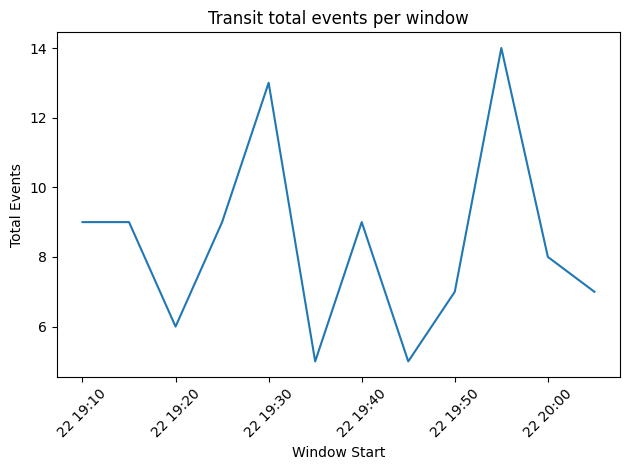

In [0]:
def plot_transit_total_events(table_name="gold_route_kpi_window"):
    """
    Plot total transit events per window (throughput signal).

    Args:
        table_name: Gold table name with route KPIs.
    """

    gold_df = spark.table(table_name)

    volume_df = (
        gold_df
        .groupBy("window_start")
        .agg(
            F.sum(
                F.coalesce(F.col("n_events_delay"), F.lit(0))
            ).alias("transit_total_events")
        )
        .orderBy("window_start")
    )

    pdf = volume_df.toPandas()

    plt.figure()
    plt.plot(pdf["window_start"], pdf["transit_total_events"])
    plt.xticks(rotation=45)
    plt.title("Transit total events per window")
    plt.xlabel("Window Start")
    plt.ylabel("Total Events")
    plt.tight_layout()
    plt.show()

plot_transit_total_events()

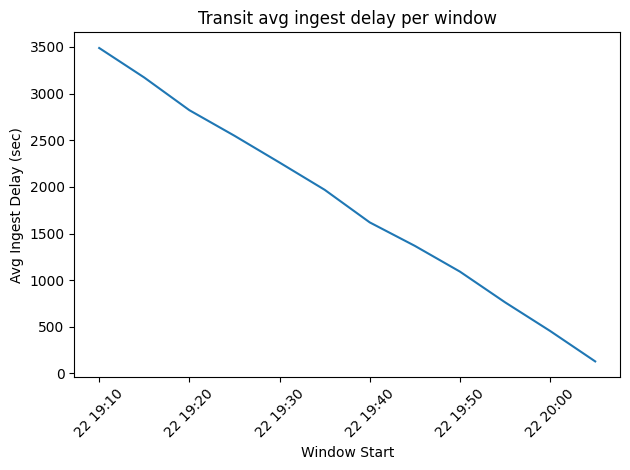

In [0]:
def plot_transit_avg_ingest_delay(table_name="gold_route_kpi_window"):
    """
    Plot average ingest delay per window (latency signal).

    Args:
        table_name: Gold table name with route KPIs.
    """

    gold_df = spark.table(table_name)

    delay_df = (
        gold_df
        .groupBy("window_start")
        .agg(
            F.avg("avg_ingest_delay_sec").alias("transit_avg_ingest_delay_sec")
        )
        .orderBy("window_start")
    )

    pdf = delay_df.toPandas()

    plt.figure()
    plt.plot(pdf["window_start"], pdf["transit_avg_ingest_delay_sec"])
    plt.xticks(rotation=45)
    plt.title("Transit avg ingest delay per window")
    plt.xlabel("Window Start")
    plt.ylabel("Avg Ingest Delay (sec)")
    plt.tight_layout()
    plt.show()

plot_transit_avg_ingest_delay()

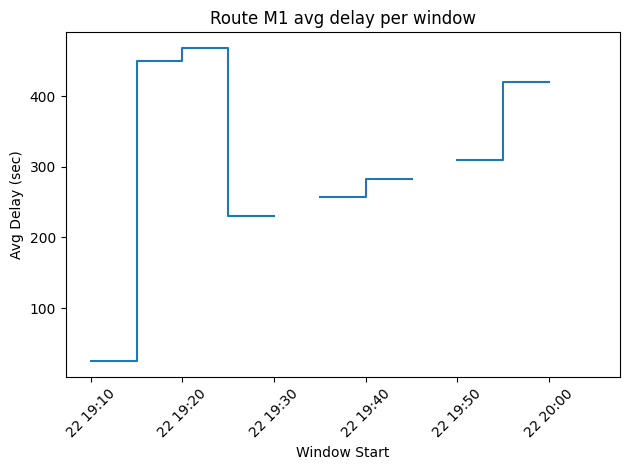

In [0]:
def plot_route_delay_window(route_id: str = "M1", freq: str = "5min"):
    """
    Plot windowed delay KPI for a single route.

    Args:
        route_id: Route identifier (e.g. "M1").
        freq: Pandas offset alias for resampling (e.g. "5min", "15min").

    Notes:
        Missing windows stay as NaN to keep gaps visible.
    """
    gold_df = spark.table("gold_route_kpi_window")

    route_pd = (
        gold_df
        .filter(F.col("route_id") == route_id)
        .select("window_start", "avg_delay_sec")
        .orderBy("window_start")
        .toPandas()
    )

    route_pd["window_start"] = pd.to_datetime(route_pd["window_start"])
    route_pd = route_pd.set_index("window_start").sort_index().asfreq(freq)

    # Ensure numeric type
    route_pd["avg_delay_sec"] = pd.to_numeric(route_pd["avg_delay_sec"], errors="coerce")

    plt.figure()
    plt.step(route_pd.index, route_pd["avg_delay_sec"], where="post")
    plt.xticks(rotation=45)
    plt.title("Route M1 avg delay per window")
    plt.xlabel("Window Start")
    plt.ylabel("Avg Delay (sec)")
    plt.tight_layout()
    plt.show()

# Example
plot_route_delay_window("M1")